# SPHINX Injection Analysis

This notebook analyzes an already completed `No-contam` retrieval for a SPHINX-injected observation. It only loads products already written by POSEIDON and computes summary diagnostics against the clean reference spectrum.

# Analysis of a completed POSEIDON retrieval — No-contam


In [28]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd

from POSEIDON.constants import M_E, R_E, R_Sun
from POSEIDON.core import (
    create_planet,
    create_star,
    define_model,
    load_data,
    read_opacities,
    set_priors,
    wl_grid_constant_R,
)
from POSEIDON.corner import generate_cornerplot
from POSEIDON.instrument import bin_spectrum_to_data
from POSEIDON.utility import read_data, read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_data, plot_spectra_retrieved


# -----------------------------
# Case configuration (edit as needed)
# -----------------------------
PLANET_NAME = "Trappist-1e"
DATA_DIR = Path("../observations_sphinx")
INSTRUMENTS = ["JWST_NIRSpec_PRISM"]
CLEAN_PATH = Path("../pandexo_spec.txt")
COMMON_LOG_PATH = Path("chi2_log_sphinx.csv")
RETRIEVAL_STRATEGY = "no_contam"

CASE_N_TRANSITS = 10
CASE_F_SPOT = 0.01
CASE_F_FAC = 0.08

OBSERVATION_FILE = (
    f"pandexo_output_{CASE_N_TRANSITS}transits_"
    f"sphinx_fspot{CASE_F_SPOT:.2f}_ffac{CASE_F_FAC:.2f}.dat"
)
MODEL_NAME = (
    f"sphinx_uncontam_{CASE_N_TRANSITS}T_"
    f"{CASE_F_SPOT:.2f}spot-{CASE_F_FAC:.2f}fac"
)

BULK_SPECIES = ["N2"]
PARAM_SPECIES = ["H2O", "CH4", "CO2", "O3"]

# Wavelength grid for model initialization
WL_MIN_UM = 0.4
WL_MAX_UM = 6.0
R_GRID = 4000


## 1) Star and planet definitions


In [29]:
# -----------------------------
# Star definition (TRAPPIST-1)
# -----------------------------
R_s = 0.1192 * R_Sun
T_s = 2566.0
met_s = 0.00
log_g_s = 5.2396

star = create_star(
    R_s,
    T_s,
    log_g_s,
    met_s,
    stellar_grid="phoenix",
)


# -----------------------------
# Planet definition (TRAPPIST-1e)
# -----------------------------
R_p = 0.917985 * R_E
M_p = 0.6356 * M_E
T_eq = 255.0

planet = create_planet(PLANET_NAME, R_p, mass=M_p, T_eq=T_eq)


## 2) Load dataset and visualize


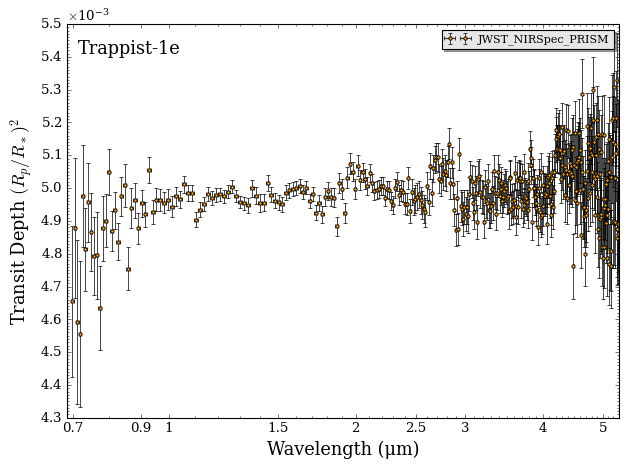

In [30]:
wl_model = wl_grid_constant_R(WL_MIN_UM, WL_MAX_UM, R_GRID)

data = load_data(
    str(DATA_DIR),
    datasets=[OBSERVATION_FILE],
    instruments=INSTRUMENTS,
    wl_model=wl_model,
)

fig_data = plot_data(data, PLANET_NAME)


## 3) Define retrieval model and priors


In [31]:
model = define_model(
    MODEL_NAME,
    BULK_SPECIES,
    PARAM_SPECIES,
    PT_profile="isotherm",
    cloud_model="cloud-free",
)

print("Free parameters:", model["param_names"])


prior_types = {
    "T": "uniform",
    "R_p_ref": "uniform",
    "log_H2O": "uniform",
    "log_CH4": "uniform",
    "log_CO2": "uniform",
    "log_O3": "uniform",
}

prior_ranges = {
    "T": [200, 400],
    "R_p_ref": [0.85 * R_p, 1.15 * R_p],
    "log_H2O": [-8, -1],
    "log_CH4": [-8, -1],
    "log_CO2": [-5, -1],
    "log_O3": [-8, -1],
}

priors = set_priors(planet, star, model, data, prior_types, prior_ranges)


Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4' 'log_CO2' 'log_O3']


## 4) Read and pre-interpolate opacities


In [32]:
""" opacity_treatment = "opacity_sampling"

# Temperature grid (K)
T_fine = np.arange(200, 401, 10)

# Pressure grid in log10(P/bar)
log_P_fine = np.arange(-2, 2.0001, 0.2)

opac = read_opacities(model, wl_model, opacity_treatment, T_fine, log_P_fine)
 """

' opacity_treatment = "opacity_sampling"\n\n# Temperature grid (K)\nT_fine = np.arange(200, 401, 10)\n\n# Pressure grid in log10(P/bar)\nlog_P_fine = np.arange(-2, 2.0001, 0.2)\n\nopac = read_opacities(model, wl_model, opacity_treatment, T_fine, log_P_fine)\n '

## 5) Plot retrieved spectrum and corner plot

## 5) Load retrieved spectrum products

This section only reads spectrum products that were already saved by POSEIDON through `read_retrieved_spectrum(...)`.
It does not launch a new retrieval or re-run MultiNest.


Generating corner plot ...


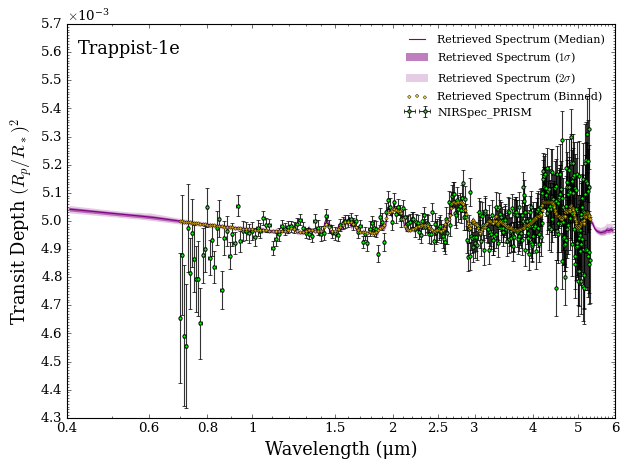

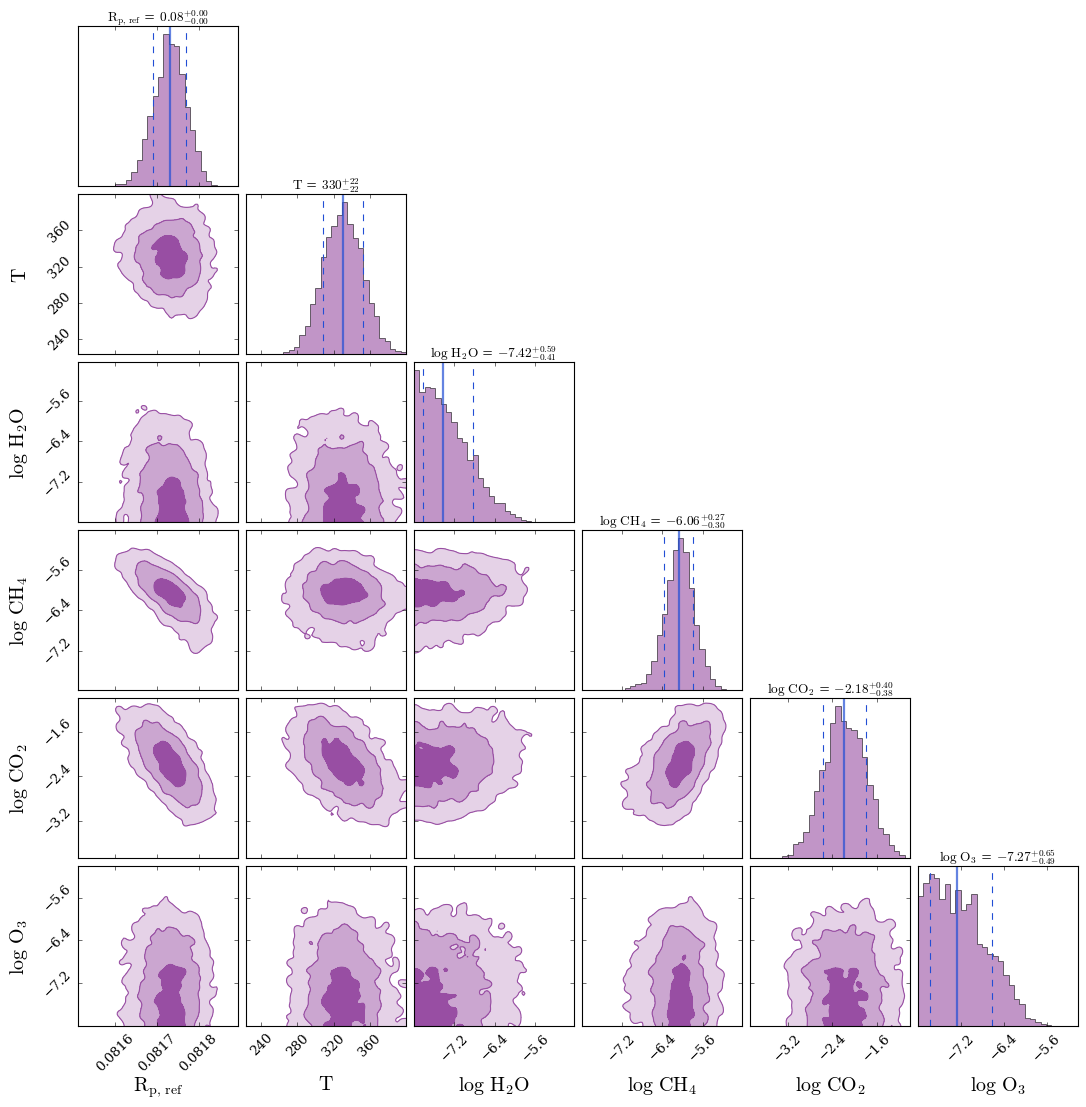

In [33]:
(
    wl_out,
    spec_low2,
    spec_low1,
    spec_median,
    spec_high1,
    spec_high2,
) = read_retrieved_spectrum(PLANET_NAME, MODEL_NAME)

spectra_median = plot_collection(spec_median, wl_out, collection=[])
spectra_low1 = plot_collection(spec_low1, wl_out, collection=[])
spectra_low2 = plot_collection(spec_low2, wl_out, collection=[])
spectra_high1 = plot_collection(spec_high1, wl_out, collection=[])
spectra_high2 = plot_collection(spec_high2, wl_out, collection=[])

fig_spec = plot_spectra_retrieved(
    spectra_median,
    spectra_low2,
    spectra_low1,
    spectra_high1,
    spectra_high2,
    PLANET_NAME,
    data,
    R_to_bin=100,
    data_labels=["NIRSpec_PRISM"],
    data_colour_list=["lime"],
)

fig_corner = generate_cornerplot(planet, model)


## 6) Clean-truth rebinned metrics (MSE / reduced $\chi^2$)

## 6) Metrics vs clean truth (explicit averaging on the observed bins)

The validation step below averages both the retrieved median spectrum and `pandexo_spec.txt` directly over the observed wavelength bins `(wl_data, half_bin)`.
This keeps the bookkeeping transparent and avoids the kind of hidden bin-mismatch that can inflate the metrics while the spectra still look visually close.


In [34]:
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd

from POSEIDON.utility import read_data


N_FREE_PARAMS = 11
LOG_PATH = COMMON_LOG_PATH
METRICS_BASIS = "median_retrieved_spectrum"


def load_clean_two_cols(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load a two-column clean spectrum file: (wl_um, depth)."""
    arr = np.genfromtxt(path, comments="#", dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.shape[1] < 2:
        raise ValueError(
            "Expected at least 2 columns (wl_um, depth) in the clean file."
        )
    wl_clean = arr[:, 0].astype(float)
    y_clean = arr[:, 1].astype(float)

    idx = np.argsort(wl_clean)
    return wl_clean[idx], y_clean[idx]


def band_average_to_bins(
    wl_src: np.ndarray,
    y_src: np.ndarray,
    centers: np.ndarray,
    halfwidths: np.ndarray,
    nsamp: int = 256,
) -> np.ndarray:
    """Average a spectrum over explicit wavelength bins using trapezoidal integration."""
    wl_src = np.asarray(wl_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    centers = np.asarray(centers, dtype=float)
    halfwidths = np.asarray(halfwidths, dtype=float)

    sort_idx = np.argsort(wl_src)
    wl_sorted = wl_src[sort_idx]
    y_sorted = y_src[sort_idx]

    out = np.empty_like(centers, dtype=float)
    for i, (center, halfwidth) in enumerate(zip(centers, halfwidths)):
        a = center - halfwidth
        b = center + halfwidth
        x = np.linspace(a, b, nsamp)
        y = np.interp(x, wl_sorted, y_sorted)
        out[i] = np.trapz(y, x) / (b - a)

    return out


def append_metrics_to_csv(log_path: Path, row: dict) -> pd.DataFrame:
    """Append one metrics row using a fixed column order."""
    columns = [
        "planet_name",
        "model_name",
        "observation",
        "retrieval_strategy",
        "metrics_basis",
        "N",
        "p",
        "dof",
        "MSE",
        "rmse",
        "rmse_ppm",
        "chi2",
        "chi2_reduced",
    ]

    new_row_df = pd.DataFrame([row], columns=columns)

    if log_path.exists():
        df_log = pd.read_csv(log_path)
        for col in columns:
            if col not in df_log.columns:
                df_log[col] = np.nan
        df_log = df_log[columns]
        df_log = pd.concat([df_log, new_row_df], ignore_index=True)
    else:
        df_log = new_row_df

    df_log.to_csv(log_path, index=False, float_format="%.10g")
    print(f"Appended row to: {log_path.resolve()}")
    return df_log


# Load clean truth and observed dataset binning
wl_clean, y_clean = load_clean_two_cols(CLEAN_PATH)
wl_data, half_bin, y_obs, err_obs = read_data(str(DATA_DIR), OBSERVATION_FILE)

sort_idx = np.argsort(np.asarray(wl_data, dtype=float))
wl_data = np.asarray(wl_data, dtype=float)[sort_idx]
half_bin = np.asarray(half_bin, dtype=float)[sort_idx]
y_obs = np.asarray(y_obs, dtype=float)[sort_idx]
err_obs = np.asarray(err_obs, dtype=float)[sort_idx]

print(f"N observed points: {len(wl_data)}")
print(f"wl_data range: {wl_data.min():.4f}–{wl_data.max():.4f} um")

model_binned = band_average_to_bins(wl_out, spec_median, wl_data, half_bin)
clean_binned = band_average_to_bins(wl_clean, y_clean, wl_data, half_bin)

if not (len(model_binned) == len(clean_binned) == len(err_obs)):
    raise ValueError("Binned arrays and errors must have the same length.")

sig = np.asarray(err_obs, dtype=float)
if np.any(sig <= 0):
    raise ValueError("Found non-positive uncertainties in err_obs; chi2 is undefined.")

resid = np.asarray(model_binned, dtype=float) - np.asarray(clean_binned, dtype=float)

N = int(resid.size)
p = int(N_FREE_PARAMS)
dof = int(max(N - p, 0))

chi2 = float(np.sum((resid / sig) ** 2))
chi2_reduced = chi2 / dof if dof > 0 else np.nan
mse = float(np.mean(resid**2))
rmse = float(np.sqrt(mse))
rmse_ppm = float(1e6 * rmse)

print("---- Metrics vs clean truth (no mask) ----")
print(f"N points      : {N}")
print(f"Free params p : {p}")
print(f"DoF           : {dof}")
print(f"MSE           : {mse:.6e}")
print(f"RMSE          : {rmse:.6e} ({rmse_ppm:.2f} ppm)")
print(f"chi2          : {chi2:.6f}")
print(f"chi2_reduced  : {chi2_reduced:.6f}")

row = {
    "planet_name": PLANET_NAME,
    "model_name": MODEL_NAME,
    "observation": OBSERVATION_FILE,
    "retrieval_strategy": RETRIEVAL_STRATEGY,
    "metrics_basis": METRICS_BASIS,
    "N": N,
    "p": p,
    "dof": dof,
    "MSE": mse,
    "rmse": rmse,
    "rmse_ppm": rmse_ppm,
    "chi2": chi2,
    "chi2_reduced": chi2_reduced,
}

df_log = append_metrics_to_csv(LOG_PATH, row)


N observed points: 385
wl_data range: 0.6988–5.2976 um
---- Metrics vs clean truth (no mask) ----
N points      : 385
Free params p : 11
DoF           : 374
MSE           : 1.810390e-09
RMSE          : 4.254868e-05 (42.55 ppm)
chi2          : 378.526077
chi2_reduced  : 1.012102
Appended row to: /mnt/c/Proyectos/Astro/gdaespec/Earth_like_Atmosphere/Retrieval Tests/sphinx_injection/chi2_log_sphinx.csv


## Visual validation of the spectral comparison

This plot overlays the observed spectrum, the clean truth averaged over the observed bins, and the retrieved median spectrum averaged over the same bins.
The lower panel shows residuals in ppm with a zoomed vertical range so small differences remain visible.


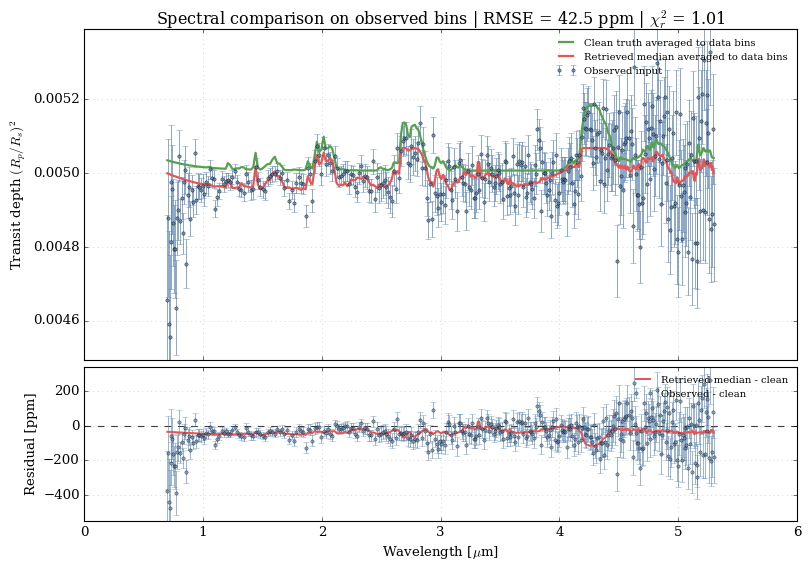

In [35]:
import matplotlib.pyplot as plt

obs_minus_clean_ppm = 1.0e6 * (np.asarray(y_obs, dtype=float) - np.asarray(clean_binned, dtype=float))
model_minus_clean_ppm = 1.0e6 * resid
err_ppm = 1.0e6 * np.asarray(err_obs, dtype=float)

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.4]},
    constrained_layout=True,
)

ax_top.errorbar(
    wl_data,
    y_obs,
    yerr=err_obs,
    fmt="o",
    ms=3.0,
    lw=0.8,
    alpha=0.7,
    color="#4c78a8",
    label="Observed input",
)
ax_top.plot(
    wl_data,
    clean_binned,
    color="#54a24b",
    lw=2.0,
    label="Clean truth averaged to data bins",
)
ax_top.plot(
    wl_data,
    model_binned,
    color="#e45756",
    lw=2.0,
    label="Retrieved median averaged to data bins",
)

y_top = np.concatenate([
    np.asarray(y_obs, dtype=float),
    np.asarray(clean_binned, dtype=float),
    np.asarray(model_binned, dtype=float),
])
y_margin = max(5.0e-6, 0.08 * (float(y_top.max()) - float(y_top.min())))
ax_top.set_ylim(float(y_top.min()) - y_margin, float(y_top.max()) + y_margin)

ax_top.set_ylabel(r"Transit depth $(R_p/R_s)^2$")
ax_top.set_title(
    f"Spectral comparison on observed bins | RMSE = {rmse_ppm:.1f} ppm | $\chi^2_r$ = {chi2_reduced:.2f}"
)
ax_top.grid(alpha=0.25)
ax_top.legend(frameon=False, fontsize=9)

ax_bottom.axhline(0.0, color="0.25", lw=1.0, ls="--")
ax_bottom.errorbar(
    wl_data,
    obs_minus_clean_ppm,
    yerr=err_ppm,
    fmt="o",
    ms=3.0,
    lw=0.8,
    alpha=0.6,
    color="#4c78a8",
    label="Observed - clean",
)
ax_bottom.plot(
    wl_data,
    model_minus_clean_ppm,
    color="#e45756",
    lw=1.8,
    label="Retrieved median - clean",
)

y_bottom = np.concatenate([obs_minus_clean_ppm, model_minus_clean_ppm, err_ppm, -err_ppm])
y_bottom_margin = max(10.0, 0.1 * (float(y_bottom.max()) - float(y_bottom.min())))
ax_bottom.set_ylim(float(y_bottom.min()) - y_bottom_margin, float(y_bottom.max()) + y_bottom_margin)

ax_bottom.set_xlabel(r"Wavelength [$\mu$m]")
ax_bottom.set_ylabel("Residual [ppm]")
ax_bottom.grid(alpha=0.25)
ax_bottom.legend(frameon=False, fontsize=9)

plt.show()
